Part 8：Model Evaluation & Comparison

In [2]:
import os
import sys

PROJECT_ROOT = os.path.abspath("..")

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

In [1]:
import torch

In [5]:
from utils.dataloader import get_dataloaders

train_loader, val_loader, test_loader = get_dataloaders(
    batch_size=32,
    num_workers=0
)

In [6]:
#test CNN
from models.cnn import FlowerCNN
from utils.evaluation import evaluate_model

cnn = FlowerCNN()
cnn.load_state_dict(
    torch.load("../weights/best_cnn.pth", map_location=DEVICE)
)
cnn.to(DEVICE)

cnn_acc, cnn_report, cnn_cm = evaluate_model(
    cnn,
    test_loader,
    DEVICE
)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_14120\3451634483.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load("../weights/best_cnn.pth", map_location=D

In [7]:
#tesst ResNet18
from models.resnet18 import create_resnet18

resnet = create_resnet18()

resnet.load_state_dict(
    torch.load("../weights/best_resnet18.pth", map_location=DEVICE)
)

resnet.to(DEVICE)

resnet_acc, resnet_report, resnet_cm = evaluate_model(
    resnet,
    test_loader,
    DEVICE
)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_14120\898033417.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load("../weights/best_resnet18.pth", map_locati

In [8]:
#test EfficientNet
from models.efficientnet import create_efficientnet

efficient = create_efficientnet()

efficient.load_state_dict(
    torch.load("../weights/best_efficientnet.pth", map_location=DEVICE)
)

efficient.to(DEVICE)

efficient_acc, efficient_report, efficient_cm = evaluate_model(
    efficient,
    test_loader,
    DEVICE
)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_14120\4219411450.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load("../weights/best_efficientnet.pth", map_l

In [9]:
#print Accuracy
print("=" * 50)
print(f"CNN Accuracy          : {cnn_acc:.4f}")
print(f"ResNet18 Accuracy     : {resnet_acc:.4f}")
print(f"EfficientNet Accuracy : {efficient_acc:.4f}")
print("=" * 50)

CNN Accuracy          : 0.1643
ResNet18 Accuracy     : 0.6526
EfficientNet Accuracy : 0.7172


In [10]:
#Classification Report
import pandas as pd

df = pd.DataFrame(efficient_report).transpose()

print(df.head())

   precision    recall  f1-score  support
0   0.223684  0.850000  0.354167     20.0
1   0.948718  0.925000  0.936709     40.0
2   0.285714  0.100000  0.148148     20.0
3   0.290323  0.250000  0.268657     36.0
4   0.814815  0.488889  0.611111     45.0


In [13]:
#save results
df.to_csv(
    "../results/cnn_report.csv"
)
df.to_csv(
    "../results/resnet18_report.csv"
)
df.to_csv(
    "../results/efficientnet_report.csv"
)

In [16]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [20]:
from utils.visualization import plot_confusion_matrix

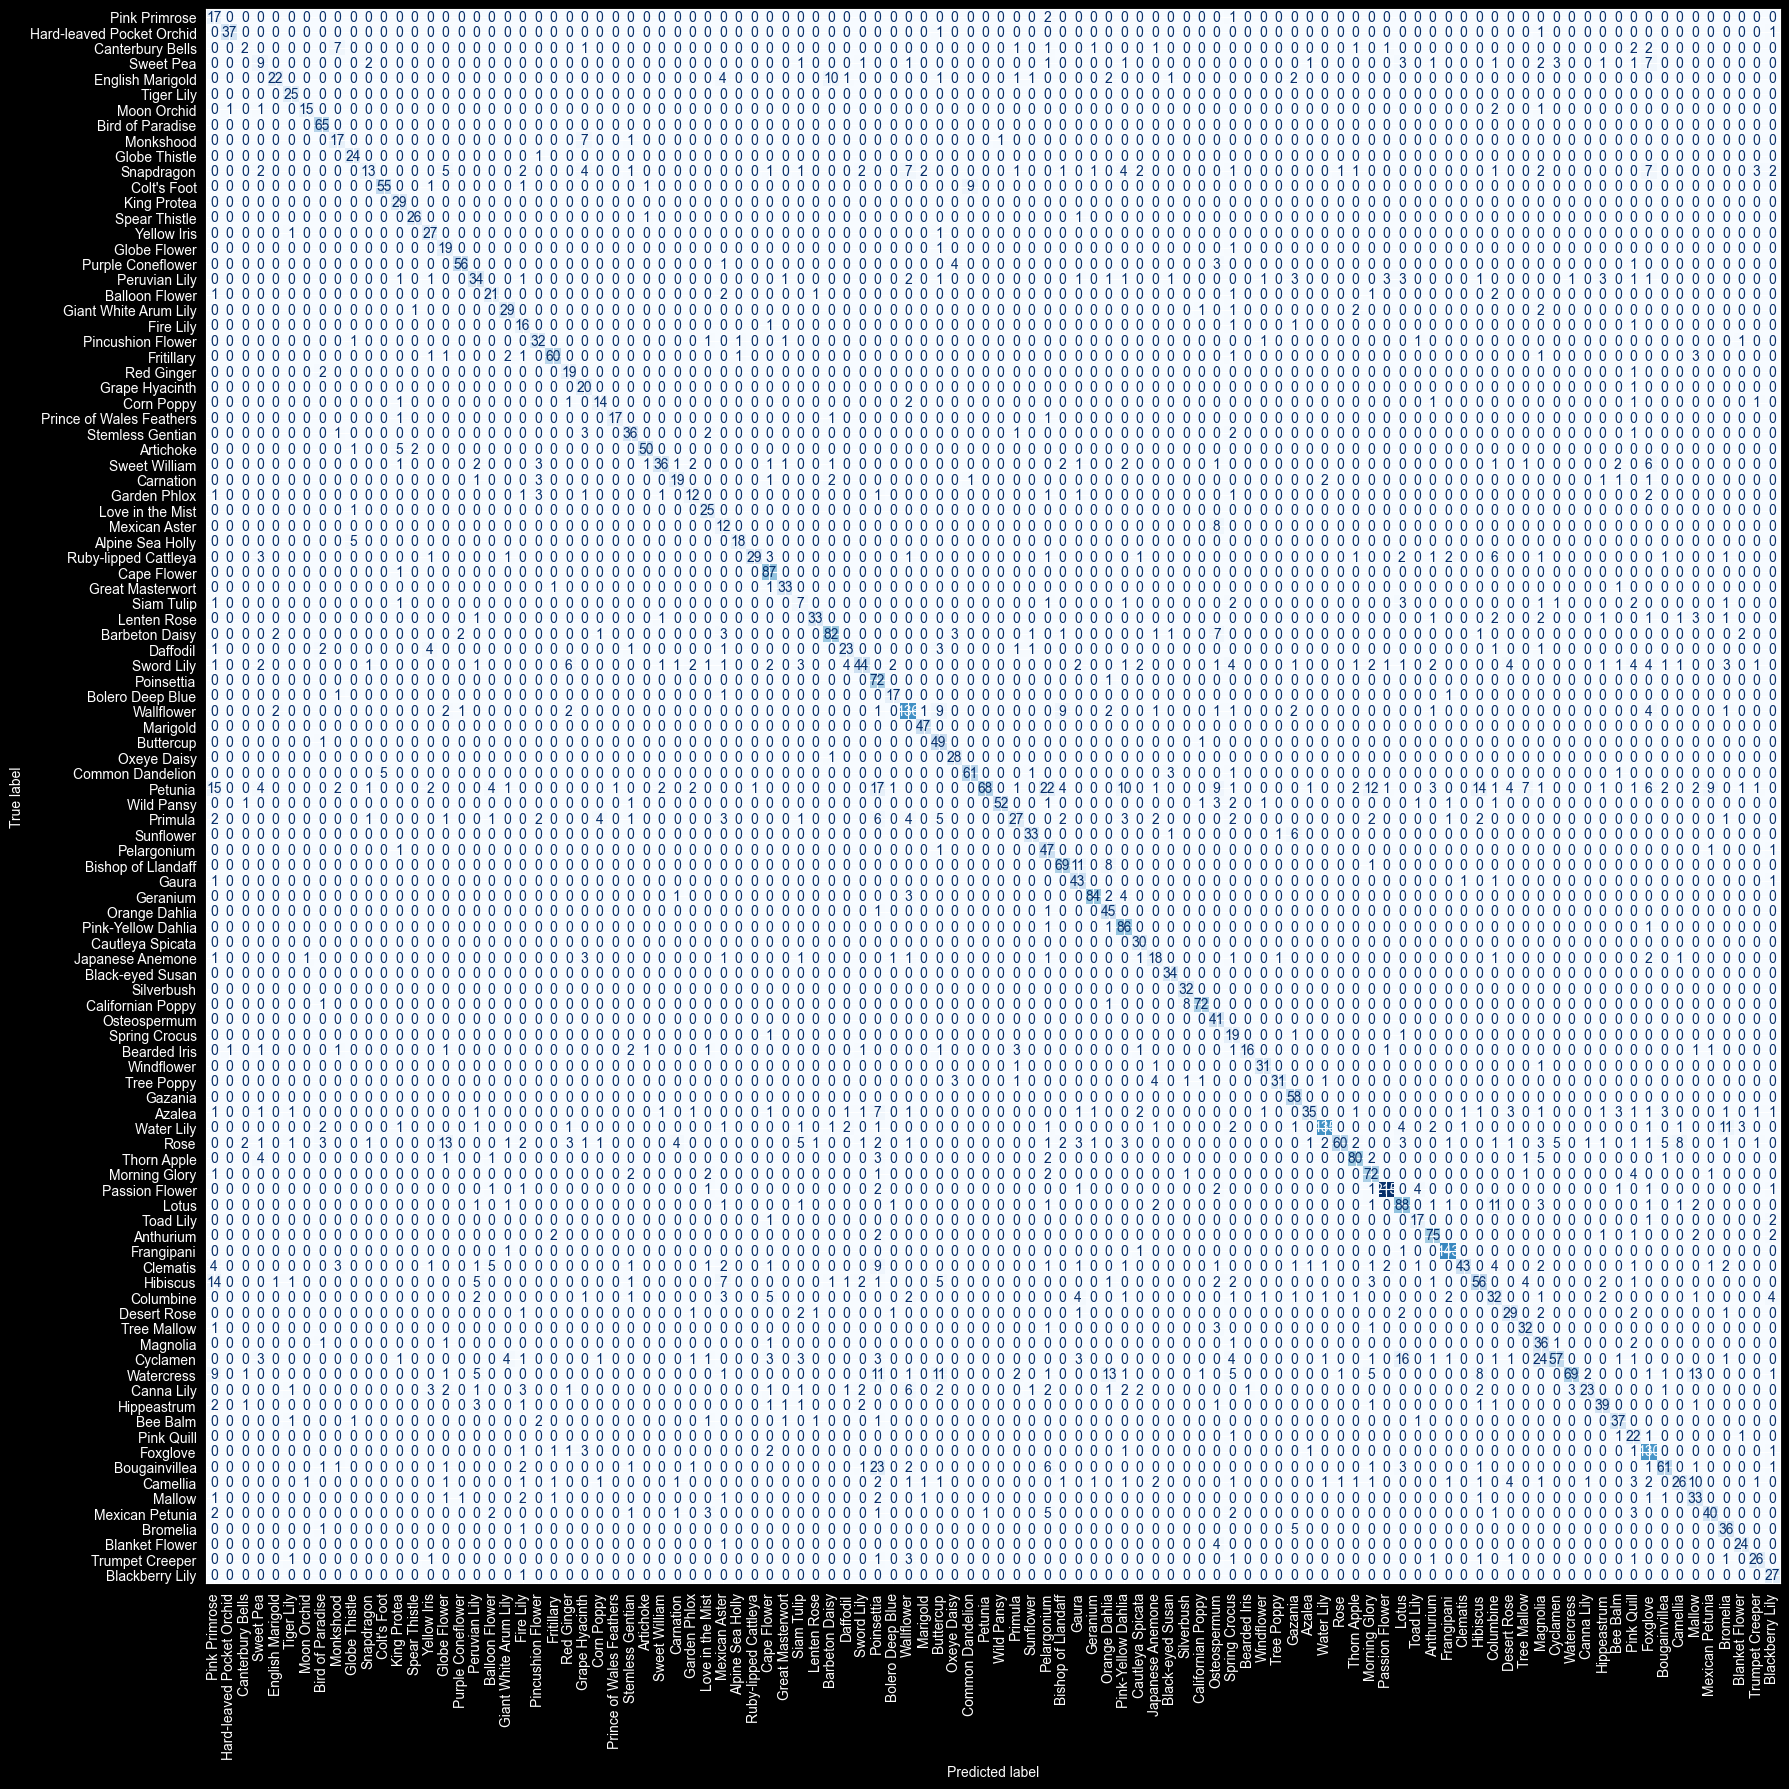

In [21]:
from utils.flower_names import ID_TO_NAME

class_names = [
    ID_TO_NAME[i]
    for i in range(102)
]

plot_confusion_matrix(
    efficient_cm,
    class_names
)

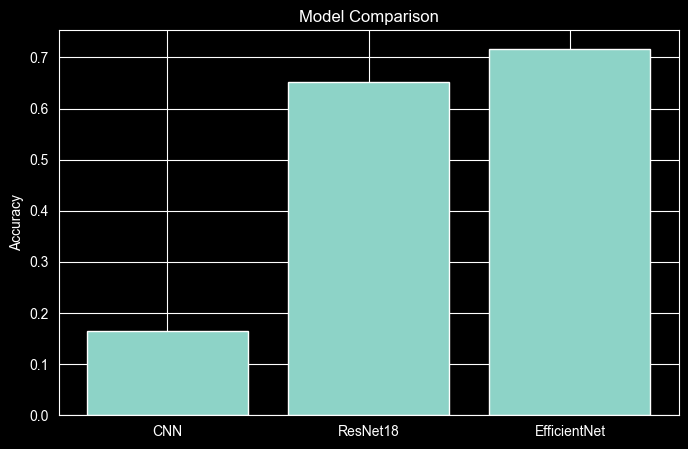

In [22]:
#Model Comparison Chart
import matplotlib.pyplot as plt

models = [
    "CNN",
    "ResNet18",
    "EfficientNet"
]

acc = [
    cnn_acc,
    resnet_acc,
    efficient_acc
]

plt.figure(figsize=(8,5))

plt.bar(models, acc)

plt.ylabel("Accuracy")

plt.title("Model Comparison")

plt.show()

In [23]:
#Save the comparison results
comparison = pd.DataFrame({

    "Model":[
        "CNN",
        "ResNet18",
        "EfficientNet"
    ],

    "Accuracy":[
        cnn_acc,
        resnet_acc,
        efficient_acc
    ]

})

comparison.to_csv(
    "../results/model_comparison.csv",
    index=False
)

comparison

,Model,Accuracy
0,CNN,0.164254
1,ResNet18,0.652626
2,EfficientNet,0.717190
